## Imports

In [109]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import json 
from matplotlib_venn import venn2
import itertools

## Degs File Pathways for Each Batch

In [110]:
deg22 = "degs_22.txt"
deg55 = "degs_55.txt"

## Combine Into One DEG File and Add Column For Batch Name

#### only need to run this once

In [111]:
pd22 = pd.read_csv(deg22, sep = "\t")
pd22['batch'] = 22

pd55 = pd.read_csv(deg22, sep = "\t")
pd55['batch'] = 55

pdCombined = pd.concat([pd22, pd55])
pdCombined.to_csv("degs_combined.txt", sep = "\t")

## Filter Degs

In [112]:
%pip install git+https://github.com/cellatlas/ec
!ec mark -p 0.1 -f 0.00 -g 10 -m 20 -o evidence.json -fmt json degs_combined.txt

Defaulting to user installation because normal site-packages is not writeable
  Cloning https://github.com/cellatlas/ec to /private/var/folders/z0/_8t5n4nd09g4xqzvkth48kp00000gn/T/pip-req-build-78f42_ed
  Running command git clone -q https://github.com/cellatlas/ec /private/var/folders/z0/_8t5n4nd09g4xqzvkth48kp00000gn/T/pip-req-build-78f42_ed
  Resolved https://github.com/cellatlas/ec to commit ebc8ad23f04d14a6b2d2443728f2f742c83efcbe
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


## Split Into DEG Batch #1 JSON and DEG Batch #2 JSON

In [115]:
combined_ev = pd.read_json("evidence.json")
ev22 = combined_ev[combined_ev["batch"] == 22]
ev55 = combined_ev[combined_ev["batch"] == 55]

df22 = ev22.rename(columns={"group": "cell_type_label", "target": "feature_identifier"})
df22["organism"] = "homo_sapiens"
df22["cell_source"] = "adipose"
df22["feature_name"] = None
df22["cell_state"] = None
df22.drop(['Unnamed: 0', 'rank', 'nnz', 'nnz_frac', 'mean', 'log_fc', 'p_raw', 'p_corr', 'batch'], axis=1, inplace=True) 

result22 = []
for _, row in df22.iterrows():
    result22.append({"extracted": {"organism": row["organism"], "cell_type_label": row["cell_type_label"], "cell_source": row["cell_source"], "cell_state": row["cell_state"], "feature_name": row["feature_name"], "feature_type": "gene"},
                   "derived": {"organism": row["organism"], "cell_type_id": None, "cell_type_label": row["cell_type_label"], "cell_source": row["cell_source"], "cell_state": row["cell_state"], "feature_name": row["feature_name"], "feature_type": "gene", "feature_identifier": row["feature_identifier"], "feature_type": "ensembl"},
                   "source": {"source_type": "deg", "source_rationale": "unfiltered", "source_id": "deg"}})

with open("evidenceJ22.json", "w") as f:
    json.dump(result22, f, indent = 4) 

df55 = ev55.rename(columns={"group": "cell_type_label", "target": "feature_identifier"})
df55["organism"] = "homo_sapiens"
df55["cell_source"] = "adipose"
df55["feature_name"] = None
df55["cell_state"] = None
df55.drop(['Unnamed: 0', 'rank', 'nnz', 'nnz_frac', 'mean', 'log_fc', 'p_raw', 'p_corr', 'batch'], axis=1, inplace=True) 

result55 = []
for _, row in df55.iterrows():
    result55.append({"extracted": {"organism": row["organism"], "cell_type_label": row["cell_type_label"], "cell_source": row["cell_source"], "cell_state": row["cell_state"], "feature_name": row["feature_name"], "feature_type": "gene"},
                   "derived": {"organism": row["organism"], "cell_type_id": None, "cell_type_label": row["cell_type_label"], "cell_source": row["cell_source"], "cell_state": row["cell_state"], "feature_name": row["feature_name"], "feature_type": "gene", "feature_identifier": row["feature_identifier"], "feature_type": "ensembl"},
                   "source": {"source_type": "deg", "source_rationale": "unfiltered", "source_id": "deg"}})

with open("evidenceJ55.json", "w") as f:
    json.dump(result55, f, indent = 4)

## Update Feature Names in EvidenceJ Files

In [94]:
gtf_fn = "/Users/nithya/Homo_sapiens.GRCh38.113.gtf"
gene_data = {}

with open(gtf_fn, 'r') as file:
    # now, we want to go through every line in the file
    for line in file:
        if line.startswith('#'):
            continue # skip comment lines in the gtf file
        columns = line.strip().split('\t') # get all the diff columns within gtf file 
        if columns[2] == 'gene':
            gene_details = columns[8].split(';')
            gene_id = ""
            gene_name = ""
            for detail in gene_details:
                detail = detail.strip();
                if detail.startswith("gene_id"):
                    gene_id_arr = detail.split(' ') # this gives the label and the id
                    gene_id = gene_id_arr[1].strip('"') # remove the double quotes surrounding the gene id
                elif detail.startswith("gene_name"):
                    gene_id_arr = detail.split(' ')
                    gene_name = gene_id_arr[1].strip('"')
        if gene_name and gene_id:
            gene_data[gene_id] = gene_name

In [95]:
def update_json(json_fn = 'evidence.json'):
    with open(json_fn, 'r') as file:
        data = json.load(file)
        
    for obj in data:
        main_obj = obj['derived']
        ensembl_id = main_obj['feature_identifier']

        if ensembl_id in gene_data.keys():
            gene = gene_data[ensembl_id]
            main_obj['feature_name'] = gene
            obj['extracted']['feature_name'] = gene

        else:
            print(main_obj)

    with open(json_fn, "w") as file:
        json.dump(data, file, indent = 4)

In [96]:
update_json(json_fn = "evidenceJ22.json")
update_json(json_fn = "evidenceJ55.json")

## Comparisons Between Post-Combined Filtered Batch JSONs and Pre-Combined Filtered Batch JSONs

#### Load Files for Comparisons

In [97]:
def load_evidence(fn):
    # we only want derived since we're going to compare gene ids
    df = pd.read_json(fn)
    derived_df = df['derived'].apply(pd.Series)
    return derived_df

In [116]:
fn1 = "evidenceJ22.json"
fn2 = "../../data/adipose_Emont2022/evidence_human/evidence.json"

fn1_ev = load_evidence(fn1)
fn2_ev = load_evidence(fn2)

#### Set Operations

In [117]:
def set_itx(a, b):
    return np.intersect1d(a, b).shape[0]
def set_itx_vals(a,b):
    return np.intersect1d(a,b)
def set_diff(a, b):
    return set_diff_vals(a,b).shape[0]
def set_diff_vals(a,b):
    return np.setdiff1d(a,b)
def create_venn(left, right, itx, set_a_name = "Set A", set_b_name = "Set B"):
    venn2(subsets = (left, right, itx), set_labels = (set_a_name, set_b_name))
    plt.show()

#### Global Gene Comparison

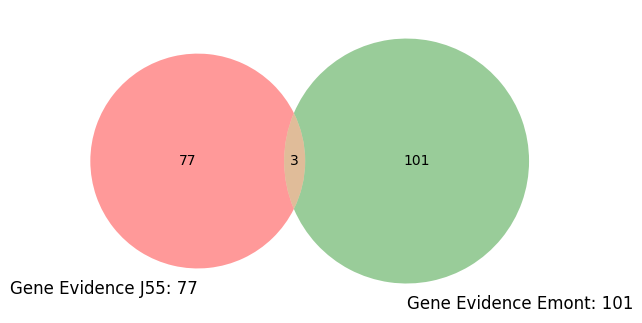

In [128]:
feature = "feature_identifier"

first = pd.Series(fn1_ev[feature].str.strip().str.upper().unique()).dropna().tolist()
second = pd.Series(fn2_ev[feature].str.strip().str.upper().unique()).dropna().tolist()

left  = set_diff(first, second)
itx   = set_itx(first, second)
right = set_diff(second, first)
itx_vals = set_itx_vals(first, second)

create_venn(left, right, itx, f'Gene Evidence J55: {left}', f'Gene Evidence Emont: {right}')

#### Global Celltype Comparison

In [119]:
def get_standard_labels(labels):
    """
    Returns the standardized labels of cell type labels using a global map
    """

    with open('../cell_type_label_map.json', 'r') as file:
        map_dict = json.load(file)
        corrected_labels = []
        for l in list(map(str.upper,labels)):
            added = False
            for key, vals in map_dict.items():
                if l in vals or l == key:
                    corrected_labels.append(key)
                    added = True
            if not added:
                corrected_labels.append(l)
    return np.array(corrected_labels)

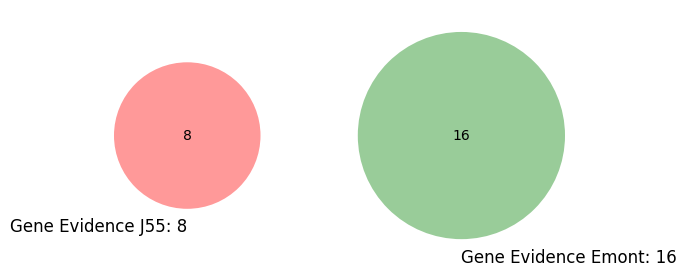

In [121]:
feature = "cell_type_label" # eventually change this to comparing based on a map we can create

first = fn1_ev[feature].str.strip().str.upper().unique()
first = get_standard_labels(first)
second = fn2_ev[feature].str.strip().str.upper().unique()
second = get_standard_labels(second)

left  = set_diff(first, second)
left_vals = set_diff_vals(first, second)

itx   = set_itx(first, second)
itx_vals = set_itx_vals(first, second)

right = set_diff(second, first)
right_vals = set_diff_vals(second, first)

create_venn(left, right, itx, f'Gene Evidence J55: {left}', f'Gene Evidence Emont: {right}')

## VVD Comparisons

In [122]:
def get_label(og_label):
    with open('../cell_type_label_map.json', 'r') as file:
        map_dict = json.load(file)

    for key, vals in map_dict.items():
        if og_label in vals or og_label == key:
            return key
    return og_label  

In [123]:
def make_3d_matrix(human_fn, deg_fn):
    """
    Finds similarites in gene expression between all cells mentioned in evidence deg and evidence human and returns a 3D matrix describing the left difference, intersection, and right difference in gene expression.

    Returns:
        pd.DataFrame: the 3D matrix describing set difference and intersection in gene expression
    """

    human_ev = load_evidence(human_fn) # gets only the derived part of evidence.json in evidence_human
    deg_ev = load_evidence(deg_fn) 

    feature = "cell_type_label"

    
    human_ev[feature] = pd.Series(human_ev[feature].str.strip().str.upper()).apply(lambda x: get_label(x))
    deg_ev[feature] = pd.Series(deg_ev[feature].str.strip().str.upper()).apply(lambda x: get_label(x))
    
    # x axis is human evidence and y axis is deg evidence

    x_labels = sorted(human_ev[feature].unique())
    y_labels = sorted(deg_ev[feature].unique())

    result_df = pd.DataFrame(index = x_labels, columns=y_labels, dtype=object)

    for x in x_labels:
        for y in y_labels:
            genes1 = set(human_ev[human_ev[feature] == x]['feature_identifier'])
            genes2 = set(deg_ev[deg_ev[feature] == y]['feature_identifier'])

            left_diff = genes1 - genes2
            intersection = genes1 & genes2
            right_diff = genes2 - genes1

            result_df.loc[x,y] = [left_diff, intersection, right_diff]

    return result_df

In [124]:
matrix = make_3d_matrix(fn1, fn2)

In [125]:
def cell_intersection_stats_numpy(matrix):
    """
    Goes through the matrix and counts the number of intersected genes to be able to easily identify similar cells

    Returns:
        pd.DataFrame: the 3D matrix describing the count in gene expression intersection
    """
    
    intersection_df = matrix.copy()
    vals = np.zeros((matrix.shape[0], matrix.shape[1], 3))
    rowids = matrix.index
    colids = matrix.columns
    for ridx, index in enumerate(matrix.index):
        for cidx, value in enumerate(matrix.columns):
            left = len(matrix.loc[index, value][0])
            intersection = len(matrix.loc[index, value][1])
            right = len(matrix.loc[index, value][2])
            # intersection_df.loc[index, value] = [left, intersection, right]
            # vals[ridx, cidx, 0] = left
            vals[ridx, cidx,:,] = [left, intersection, right]

    
    return (vals, rowids, colids)

def cell_intersection_stats(matrix):
    """
    Goes through the matrix and counts the number of intersected genes to be able to easily identify similar cells

    Returns:
        pd.DataFrame: the 3D matrix describing the count in gene expression intersection
    """
    
    intersection_df = matrix.copy()
    for index in matrix.index:
        for value in matrix.columns:
            left = len(matrix.loc[index, value][0])
            intersection = len(matrix.loc[index, value][1])
            right = len(matrix.loc[index, value][2])
            intersection_df.loc[index, value] = [left, intersection, right]
    
    return intersection_df

In [126]:
cell_similarity_matrix = cell_intersection_stats(matrix)
# before making vals, make sure the rows and columns are sorted correctly
(vals, rowids, colids) = cell_intersection_stats_numpy(matrix)

#### Count Version

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (0,) and arg 1 with shape (8,).

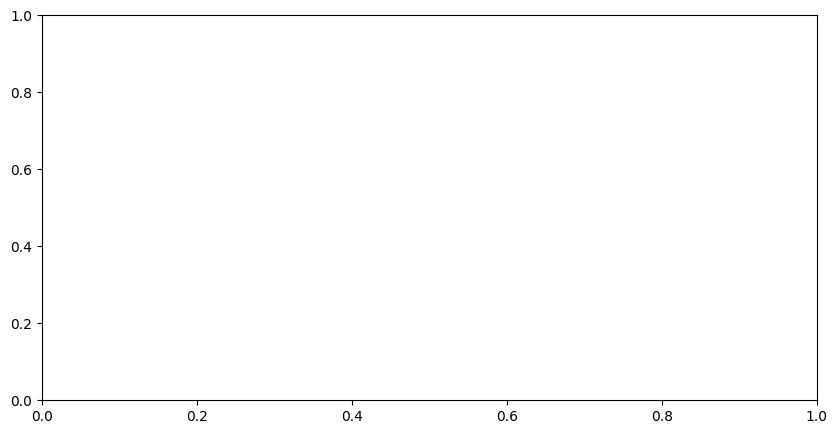

In [127]:
fig, ax = plt.subplots(figsize=(10,5))

left = np.diag(vals[:,:,0])
itx = np.diag(vals[:,:,1])
right = np.diag(vals[:,:,2])

y1 = left 
y2 = itx 
y3 = right 

human_cells = cell_similarity_matrix.index
df_cells = cell_similarity_matrix.columns

x_axis = np.array([f"{h} and {d}" for h, d in itertools.product(human_cells, df_cells) if h == d])

ax.bar(x_axis, y1, color='r', label='Left Difference (J55)')
ax.bar(x_axis, y2, bottom=y1, color='b', label='Intersection')
ax.bar(x_axis, y3, bottom=y1+y2, color='g', label='Right Difference (55)')

ax.set_xticklabels(x_axis, rotation=90, fontsize=8)

ax.set(
    **{
        "xlabel" : "Cell Combinations",
        "ylabel": "Gene Expression Similarities Found",
        "title": "VVD"
    }
)
ax.legend(bbox_to_anchor=(1,0.5))

# Show the plot
fig.show()

#### Percentage Version

/var/folders/z0/_8t5n4nd09g4xqzvkth48kp00000gn/T/ipykernel_60791/3590768239.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_axis, rotation=90, fontsize=8)
/var/folders/z0/_8t5n4nd09g4xqzvkth48kp00000gn/T/ipykernel_60791/3590768239.py:34: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


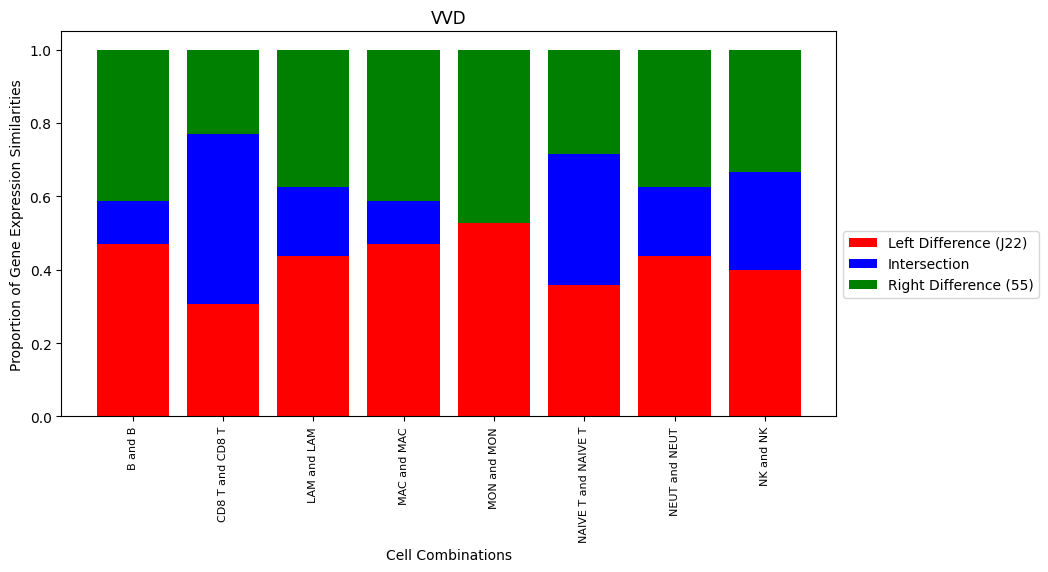

In [59]:
fig, ax = plt.subplots(figsize=(10,5))

total = np.diag(vals[:,:,0] + vals[:,:,1] + vals[:,:,2])

left = np.diag(vals[:,:,0]/total)
itx = np.diag(vals[:,:,1]/total)
right = np.diag(vals[:,:,2]/total)

y1 = left 
y2 = itx 
y3 = right 

human_cells = cell_similarity_matrix.index
df_cells = cell_similarity_matrix.columns

x_axis = np.array([f"{h} and {d}" for h, d in itertools.product(human_cells, df_cells) if h == d])

ax.bar(x_axis, y1, color='r', label='Left Difference (J22)')
ax.bar(x_axis, y2, bottom=y1, color='b', label='Intersection')
ax.bar(x_axis, y3, bottom=y1+y2, color='g', label='Right Difference (55)')

ax.set_xticklabels(x_axis, rotation=90, fontsize=8)

ax.set(
    **{
        "xlabel" : "Cell Combinations",
        "ylabel": "Proportion of Gene Expression Similarities",
        "title": "VVD"
    }
)
ax.legend(bbox_to_anchor=(1,0.5))

# Show the plot
fig.show()